# AG_PRAXIS NB03 — Feature Distributions and Separability

This notebook is about the features themselves rather than about any model built on
them. The files hold 45 columns, two of which hold the same value in every row of the
corpus and are dropped, so 43 are left. What I want to know before building anything is
what is actually in those 43: how each one is distributed, which of them are saying the
same thing as each other, and how much any single one of them knows about the attack
class on its own.

That last question is the one that matters most for what comes after. If one feature
separates the classes almost perfectly by itself, then a model reaching a high score has
not necessarily learned anything about attacks, and an attribution method pointing at
that feature has not explained much either. If no single feature separates a pair of
classes, then that pair is where the model has to do real work, and it is where the
weak-class results will be decided.

Six things get produced. A summary of all 43 features. A correlation matrix ordered so
that related features sit together. Distributions of the timing features against
distributions from the other two families. Two rankings by mutual information, one
against all nineteen classes and one against the four classes this project has fixed as
its targets. The per-capture means of the strongest features, to show whether a feature
moves between recordings of the same attack. And a matrix of how separable each pair of
classes is by a single feature.

Nothing is trained. The mutual information and the AUC are measurements of one column at
a time against the label, and neither leaves a model behind. Everything written goes to
the artefacts folder on Drive, because a notebook running in Colab cannot commit and a
file written into the cloned repository lives exactly as long as the session does.

Mount Drive, clone the repository so that `src/` can be imported, and record the commit
the results belong to. The repository is read from and never written to.

In [29]:
import os
import subprocess
import sys
from datetime import date
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AGREWAL14/AG_PRAXIS.git"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_ROOT = Path("/content/repo")
    if REPO_ROOT.exists():
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    REPO_ROOT = Path.cwd()
    while not (REPO_ROOT / "config" / "base.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def git(*args):
    return subprocess.run(
        ["git", "-C", str(REPO_ROOT), *args], capture_output=True, text=True
    ).stdout.strip()


GIT_SHA = git("rev-parse", "--short", "HEAD")
GIT_BRANCH = git("rev-parse", "--abbrev-ref", "HEAD")
GIT_DIRTY = bool(git("status", "--porcelain"))
RUN_DATE = date.today().isoformat()

print(f"colab     : {IN_COLAB}")
print(f"repo root : {REPO_ROOT}")
print(f"git sha   : {GIT_SHA} on {GIT_BRANCH}" + ("   WORKING TREE DIRTY" if GIT_DIRTY else ""))
print(f"run date  : {RUN_DATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab     : True
repo root : /content/repo
git sha   : 835f17a on main
run date  : 2026-08-03


Paths and the seed come from `config/base.yaml`. The column list comes from
`data/processed/schema.json`, and the tiers, the class labels and the list of columns
that never vary come from `data/processed/capture_inventory.json`, so this notebook uses
the inventory that was already checked rather than deriving a second one that could
quietly disagree with it.

Three thresholds are set here rather than chosen later once the numbers are visible. A
feature is called near-empty if it is zero in more than 90 percent of rows. A pair of
features is called near-duplicate at an absolute correlation of 0.95. A pair of classes
is called separable by one feature at an AUC of 0.9.

`FAST` changes how much of each file is read. At `FAST=1` the reader takes the opening
one percent of each file, and the opening rows of a session are a contiguous slice of it
rather than a sample of it, so a distribution can look far tighter than it is. Steps 2,
5 and 7 have to be re-run at `FAST=0` before any figure is used.

In [30]:
import os
os.environ["FAST"] = "0"

In [31]:
import json
import random
import time

import numpy as np
import pandas as pd
import yaml

from src import captures as cap
from src import eda
from src import inventory as inv
from src import leakage as leak

CFG = inv.load_config(REPO_ROOT)

SEED = CFG["seed"]
TRAIN_DIR = Path(CFG["paths"]["train_dir"])
TEST_DIR = Path(CFG["paths"]["test_dir"])
ARTIFACTS = Path(CFG["paths"]["artifacts"])
OUT_DIR = ARTIFACTS / "NB03"
FIG_DIR = OUT_DIR / "results" / "figures"

PROCESSED = REPO_ROOT / "data" / "processed"
for required in ("schema.json", "capture_inventory.json"):
    if not (PROCESSED / required).exists():
        raise FileNotFoundError(f"{PROCESSED / required} not found in the repository.")

SCHEMA = json.loads((PROCESSED / "schema.json").read_text())
INVENTORY = json.loads((PROCESSED / "capture_inventory.json").read_text())

if IN_COLAB and not ARTIFACTS.exists():
    raise FileNotFoundError(
        f"{ARTIFACTS} does not exist. Drive is not mounted, or the artefacts path in "
        "config/base.yaml is wrong. Nothing this notebook writes would survive."
    )
FIG_DIR.mkdir(parents=True, exist_ok=True)

FAST = os.environ.get("FAST", "1") == "1"
READ_FRAC = CFG["fast_mode"]["subsample_frac"] if FAST else 1.0

# Rows kept from each file for the analyses that need the rows themselves rather than
# their moments. The same number from every file, so that a capture with more rows
# cannot set the shape of a distribution on its own.
ROWS_PER_FILE = 1_000 if FAST else 5_000

# Mutual information and the pairwise AUC read whatever class distribution they are
# given, and the largest class here holds a fifth of the corpus, so both get an equal
# draw per class instead.
MI_ROWS_PER_CLASS = 400 if FAST else 2_000
AUC_ROWS_PER_CLASS = 400 if FAST else 2_000

# Fixed before any result exists.
ZERO_SHARE_FLAG = 0.90
CORRELATION_FLAG = 0.95
SEPARABLE_AUC = 0.90

# The four classes this project targets, fixed in the pre-registration.
TARGET_CLASSES = ["Recon-VulScan", "Recon-OS_Scan", "MQTT-DDoS-Publish_Flood", "Spoofing"]

TIER_OF = {label: entry["tier"] for label, entry in INVENTORY["classes"].items()}
ROW_COUNTS = INVENTORY["rows_per_capture_file"]
GROUP6_ORDER = ["Benign", "DDoS", "DoS", "MQTT", "Recon", "Spoofing"]

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 60)

print(f"seed        : {SEED}")
print(f"train dir   : {TRAIN_DIR}   exists={TRAIN_DIR.exists()}")
print(f"test dir    : {TEST_DIR}   exists={TEST_DIR.exists()}")
print(f"output dir  : {OUT_DIR}")
print(f"figures     : {FIG_DIR}")
print()
print(f"schema.json            written on {SCHEMA['generated_on']} at sha {SCHEMA['git_sha']}")
print(f"capture_inventory.json written on {INVENTORY['generated_on']} at sha {INVENTORY['git_sha']}")
print(f"  {INVENTORY['n_classes']} classes in {INVENTORY['n_files']} files, {INVENTORY['total_rows']:,} rows")
print()
print(f"FAST                  : {int(FAST)}")
print(f"reads                 : {'every row of every file' if not FAST else f'the first {READ_FRAC:.0%} of each file'}")
print(f"rows kept per file    : {ROWS_PER_FILE:,}")
print(f"rows per class for mutual information : {MI_ROWS_PER_CLASS:,}")
print(f"rows per class for pairwise AUC       : {AUC_ROWS_PER_CLASS:,}")
print(f"near-empty if zero in more than       : {ZERO_SHARE_FLAG:.0%} of rows")
print(f"near-duplicate at absolute correlation: {CORRELATION_FLAG}")
print(f"separable by one feature at AUC       : {SEPARABLE_AUC}")
print(f"target classes        : {', '.join(TARGET_CLASSES)}")
if FAST:
    print()
    print("FAST=1. Each file is read from its opening rows only, which is a contiguous")
    print("slice of a session rather than a sample of it. Steps 2, 5 and 7 need FAST=0")
    print("before their figures are final.")

seed        : 42
train dir   : /content/drive/MyDrive/AG_PRAXIS_data/csv/train   exists=True
test dir    : /content/drive/MyDrive/AG_PRAXIS_data/csv/test   exists=True
output dir  : /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03
figures     : /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/results/figures

schema.json            written on 2026-08-02 at sha d3f634b
capture_inventory.json written on 2026-08-02 at sha ba7bd64
  19 classes in 72 files, 8,775,013 rows

FAST                  : 0
reads                 : every row of every file
rows kept per file    : 5,000
rows per class for mutual information : 2,000
rows per class for pairwise AUC       : 2,000
near-empty if zero in more than       : 90% of rows
near-duplicate at absolute correlation: 0.95
separable by one feature at AUC       : 0.9
target classes        : Recon-VulScan, Recon-OS_Scan, MQTT-DDoS-Publish_Flood, Spoofing


The seed is set before anything that draws. Two things here draw: the rows kept from each
file, and the nearest-neighbour estimator behind mutual information. Both take the
generator built from this seed, so a re-run reads the same rows and returns the same
scores.

In [32]:
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
print(f"seeded with {SEED}")

seeded with 42


Two columns come out before anything else touches the data. The inventory records `DHCP`
and `Drate` as holding a single value across the whole corpus. A column with no variation
has no distribution to plot, no correlation with anything, and no information about any
label, so every table below would carry two rows of zeros and one flag that means nothing.

In [33]:
DROPPED = list(INVENTORY["columns_constant_everywhere"])
EXPECTED_DROPPED = ["DHCP", "Drate"]
FEATURES = [c for c in SCHEMA["columns"] if c not in DROPPED]

print(f"columns in the files       : {len(SCHEMA['columns'])}")
print(f"constant across the corpus : {DROPPED}")
print(f"features described here    : {len(FEATURES)}")

if sorted(DROPPED) != sorted(EXPECTED_DROPPED):
    print()
    print(f"The inventory names {DROPPED}, not {EXPECTED_DROPPED}. Read it before continuing.")

still_there = [c for c in EXPECTED_DROPPED if c in FEATURES]
assert not still_there, f"{still_there} should have been dropped and was not"
print()
print(", ".join(FEATURES))

columns in the files       : 45
constant across the corpus : ['DHCP', 'Drate']
features described here    : 43

Header_Length, Protocol Type, Duration, Rate, Srate, fin_flag_number, syn_flag_number, rst_flag_number, psh_flag_number, ack_flag_number, ece_flag_number, cwr_flag_number, ack_count, syn_count, fin_count, rst_count, HTTP, HTTPS, DNS, Telnet, SMTP, SSH, IRC, TCP, UDP, ARP, ICMP, IGMP, IPv, LLC, Tot sum, Min, Max, AVG, Std, Tot size, IAT, Number, Magnitue, Radius, Covariance, Variance, Weight


Step 4 contrasts the timing features against features from the other two families, so the
features have to be sorted into families first. The rule is in `src/inventory.py` and
works from column names alone, which is a guess about what a column measures rather than
knowledge of it. If `config/feature_families.yaml` has been filled in and marked
reviewed, that file wins instead.

In [34]:
FAMILY_FILE = REPO_ROOT / "config" / "feature_families.yaml"
raw_families = yaml.safe_load(FAMILY_FILE.read_text()) if FAMILY_FILE.exists() else None

if raw_families and raw_families.get("families") and raw_families.get("status") == "reviewed":
    FAMILIES = {
        name: [c for c in columns if c in FEATURES]
        for name, columns in raw_families["families"].items()
    }
    FAMILY_SOURCE = "config/feature_families.yaml, reviewed"
else:
    assignment = inv.assign_families(FEATURES)
    FAMILIES = {name: columns for name, columns in assignment["families"].items() if columns}
    FAMILY_SOURCE = "src.inventory.assign_families, from column names"

FAMILY_OF = {c: name for name, columns in FAMILIES.items() for c in columns}

print(f"families from : {FAMILY_SOURCE}")
print()
for name, columns in FAMILIES.items():
    print(f"{name:<12} {len(columns):>2}   {', '.join(columns)}")
print()
print(f"features in no family : {[c for c in FEATURES if c not in FAMILY_OF] or 'none'}")

families from : src.inventory.assign_families, from column names

timing        4   Duration, Rate, Srate, IAT
protocol     27   Header_Length, Protocol Type, fin_flag_number, syn_flag_number, rst_flag_number, psh_flag_number, ack_flag_number, ece_flag_number, cwr_flag_number, ack_count, syn_count, fin_count, rst_count, HTTP, HTTPS, DNS, Telnet, SMTP, SSH, IRC, TCP, UDP, ARP, ICMP, IGMP, IPv, LLC
statistical  12   Tot sum, Min, Max, AVG, Std, Tot size, Number, Magnitue, Radius, Covariance, Variance, Weight

features in no family : none


Now the files. `parse_capture` reads the class, the capture number and the partition out
of each filename, and `capture_key` decides what counts as one recording: for a class
recorded several times a train chunk and a test chunk carrying the same number are two
different sessions, and for a class recorded once the two shipped files are the two halves
of one session and are pooled back together. Step 6 asks whether a feature shifts between
recordings, so it depends entirely on this key being right.

In [35]:
train_files = sorted(TRAIN_DIR.glob("*.csv"))
test_files = sorted(TEST_DIR.glob("*.csv"))
ALL_FILES = train_files + test_files

files = pd.DataFrame(
    [{"file": p.name, "path": str(p), **cap.parse_capture(p.name)} for p in ALL_FILES]
)
files["tier"] = files["label"].map(TIER_OF)
files["group6"] = files["label"].map(cap.group_six)
files["rows"] = files["file"].map(ROW_COUNTS)
files["capture"] = [
    leak.capture_key(r.capture_id, r.partition, r.tier) for r in files.itertuples(index=False)
]

unknown = files.loc[files["tier"].isna(), "label"].unique().tolist()
assert not unknown, f"labels missing from the inventory: {unknown}"
assert "UNMAPPED" not in set(files["group6"]), "a label did not map into the 6-class grouping"

CAPTURE_LABEL = files.drop_duplicates("capture").set_index("capture")["label"]
CAPTURE_GROUP6 = files.drop_duplicates("capture").set_index("capture")["group6"]
CLASS_ORDER = (
    files.drop_duplicates("label")
    .sort_values(["group6", "label"])["label"]
    .tolist()
)

print(f"files    : {len(files)}")
print(f"classes  : {files['label'].nunique()}")
print(f"captures : {files['capture'].nunique()}")
print()
print(
    files.groupby(["group6", "label"], sort=True)
    .agg(files=("file", "size"), captures=("capture", "nunique"), rows=("rows", "sum"))
    .to_string()
)

files    : 72
classes  : 19
captures : 61

                                  files  captures     rows
group6   label                                            
Benign   Benign                       2         1   230339
DDoS     DDoS-ICMP                   10        10  1887175
         DDoS-SYN                     5         5   974359
         DDoS-TCP                     5         5   987063
         DDoS-UDP                    10        10  1998026
DoS      DoS-ICMP                     5         5   514724
         DoS-SYN                      5         5   540498
         DoS-TCP                      5         5   462480
         DoS-UDP                      5         5   704503
MQTT     MQTT-DDoS-Connect_Flood      2         1   214952
         MQTT-DDoS-Publish_Flood      2         1    36039
         MQTT-DoS-Connect_Flood       2         1    15904
         MQTT-DoS-Publish_Flood       2         1    52881
         MQTT-Malformed_Data          2         1     6877
Recon    Reco

One pass over the files does both jobs. While a file is open, the count, mean, second and
third central moments, range and zero count of every feature are computed over every row
that was read. Those numbers combine afterwards into the summary table and into the
per-capture means, and combining them gives the same answer as reading the whole corpus at
once, which is the point, because the whole corpus does not fit in memory. Then a fixed
number of rows is drawn at random from the file and kept.

The kept rows are what the correlation matrix, the distribution plots, the mutual
information and the AUC all read. The draw is the same size for every file, so the classes
with the most recordings contribute the most rows but no single recording dominates.

Rows holding a non-finite value are dropped and counted rather than silently absorbed. An
infinity in one row would set the maximum of a feature by itself and make its summary row
unreadable.

In [36]:
MOMENT_COLUMNS = ["feature", "n", "mean", "m2", "m3", "min", "max", "n_zero"]

moment_rows = []
sample_frames = []
rows_read = 0
rows_dropped = 0

started = time.perf_counter()
for i, row in enumerate(files.itertuples(index=False), start=1):
    frame = cap.read_capture(row.path, frac=READ_FRAC, known_rows=ROW_COUNTS.get(row.file))
    frame = frame[FEATURES].astype("float32")
    rows_read += len(frame)

    keep = leak.finite_rows(frame)
    rows_dropped += int((~keep).sum())
    frame = frame.loc[keep]

    m = eda.file_moments(frame, FEATURES)
    m["file"] = row.file
    m["capture"] = row.capture
    m["label"] = row.label
    moment_rows.append(m)

    kept = leak.sample_rows(frame, ROWS_PER_FILE, RNG).copy()
    kept["__file"] = row.file
    kept["__capture"] = row.capture
    kept["__label"] = row.label
    kept["__group6"] = row.group6
    sample_frames.append(kept)

    del frame
    if i % 10 == 0 or i == len(files):
        print(f"  {i:>3}/{len(files)} files   {rows_read:,} rows read   {time.perf_counter() - started:,.0f}s")

MOMENTS = pd.concat(moment_rows, ignore_index=True)
MOMENTS["var"] = MOMENTS["m2"] / MOMENTS["n"]
CORPUS_MOMENTS = eda.combine_moments([m[MOMENT_COLUMNS] for m in moment_rows])
SAMPLE = pd.concat(sample_frames, ignore_index=True)

print()
print(f"rows read              : {rows_read:,} of {sum(ROW_COUNTS.values()):,} in the corpus")
print(f"rows with a non-finite value, dropped : {rows_dropped:,}")
print(f"rows kept for the analyses that need rows : {len(SAMPLE):,}")
print(f"                                          ({SAMPLE[FEATURES].memory_usage().sum() / 1e6:,.0f} MB of features)")
print()
print("rows kept per class")
print(SAMPLE.groupby(["__group6", "__label"]).size().to_string())

   10/72 files   573,270 rows read   8s
   20/72 files   2,312,309 rows read   26s
   30/72 files   4,339,415 rows read   47s
   40/72 files   5,883,025 rows read   63s
   50/72 files   7,017,530 rows read   76s
   60/72 files   7,267,917 rows read   80s
   70/72 files   8,555,364 rows read   94s
   72/72 files   8,775,013 rows read   96s

rows read              : 8,775,013 of 8,775,013 in the corpus
rows with a non-finite value, dropped : 0
rows kept for the analyses that need rows : 334,589
                                          (58 MB of features)

rows kept per class
__group6  __label                
Benign    Benign                     10000
DDoS      DDoS-ICMP                  50000
          DDoS-SYN                   25000
          DDoS-TCP                   25000
          DDoS-UDP                   50000
DoS       DoS-ICMP                   25000
          DoS-SYN                    25000
          DoS-TCP                    25000
          DoS-UDP                    2500

Colours and axis styling are set once so that every figure in the notebook reads the same
way, and `save_figure` writes each one at 300 dpi and records the filename. The figures go
to a `results/figures` folder inside the artefacts directory on Drive, mirroring the path
they belong at in the repository, because Colab cannot commit and anything written into
the cloned repository disappears with the session. They are moved across from the Mac
afterwards.

In [37]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

INK, MUTED, GRID, RULE = "#0b0b0b", "#52514e", "#e6e5e1", "#c9c8c3"
GROUP_COLOUR = {
    "Benign": "#2a78d6",
    "DDoS": "#eb6834",
    "DoS": "#8f4fbf",
    "MQTT": "#118a7e",
    "Recon": "#c9a227",
    "Spoofing": "#c0392b",
}

FIGURES = []


def style(ax, *, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(RULE)
    ax.tick_params(colors=MUTED, length=0, labelsize=8)


def group_legend(ax, groups=None, **kwargs):
    groups = groups or GROUP6_ORDER
    handles = [
        Line2D([], [], marker="o", linestyle="none", color=GROUP_COLOUR[g], label=g) for g in groups
    ]
    legend = ax.legend(handles=handles, frameon=False, fontsize=8, **kwargs)
    for text in legend.get_texts():
        text.set_color(MUTED)


def save_figure(fig, name, *, show=True):
    path = FIG_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    FIGURES.append(path)
    print(f"wrote {path.name}   {path.stat().st_size / 1e3:,.0f} kB")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return path


print(f"figures will be written to {FIG_DIR}")
print("at 300 dpi, and copied into results/figures/ from the Mac afterwards")

figures will be written to /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/results/figures
at 300 dpi, and copied into results/figures/ from the Mac afterwards


## Step 2 — what is in each of the 43 features

The first table is the one I would want if I had never seen this dataset. Mean and
standard deviation say where a feature sits and how far it moves. Minimum and maximum say
whether it is bounded, which for the protocol flags should mean zero and one. The median
against the mean says whether the distribution is lopsided, and the skewness puts a number
on that. The share of zeros says whether the feature is mostly absent, which for a
protocol indicator is the normal case and is worth knowing before reading anything else
about it.

Every column here except the median is computed over every row that was read, by combining
the per-file moments. The median needs the values in memory at once to be exact, so it is
taken from the rows that were kept and is marked as such.

In [38]:
SAMPLE_MEDIANS = SAMPLE[FEATURES].median()
SUMMARY = eda.summary_table(CORPUS_MOMENTS, medians=SAMPLE_MEDIANS)
SUMMARY["family"] = SUMMARY["feature"].map(FAMILY_OF)
SUMMARY = SUMMARY.set_index("feature").loc[FEATURES].reset_index()
SUMMARY["near_empty"] = SUMMARY["zero_share"] > ZERO_SHARE_FLAG

printable = SUMMARY[
    ["feature", "family", "mean", "std", "min", "median", "max", "skew", "zero_share"]
].copy()
for column in ("mean", "std", "min", "median", "max", "skew"):
    printable[column] = printable[column].map(lambda v: f"{v:,.4g}" if pd.notna(v) else "")
printable["zero_share"] = SUMMARY["zero_share"].map(lambda v: f"{v:.3f}")
printable["flag"] = np.where(SUMMARY["near_empty"], "near-empty", "")

print(f"all {len(SUMMARY)} features over {int(SUMMARY['n'].iloc[0]):,} rows")
print("the median column comes from the kept rows, every other column from every row read")
print()
print(printable.to_string(index=False))

all 43 features over 8,775,013 rows
the median column comes from the kept rows, every other column from every row read

        feature      family      mean       std    min   median       max     skew zero_share       flag
  Header_Length    protocol 2.996e+04 2.824e+05      0      112 9.897e+06    20.91      0.249           
  Protocol Type    protocol     8.047     6.305      0        6        17   0.4793      0.000           
       Duration      timing     64.64     7.853      0       64       255     16.3      0.000           
           Rate      timing 1.574e+04 4.001e+04      0    65.05 2.097e+06    9.083      0.038           
          Srate      timing 1.574e+04 4.001e+04      0    65.05 2.097e+06    9.083      0.038           
fin_flag_number    protocol  0.005123   0.03416      0        0         1    8.061      0.971 near-empty
syn_flag_number    protocol    0.1572    0.3369      0        0         1    1.847      0.790           
rst_flag_number    protocol   0.03952   

The flagged features are the ones worth pausing on. A feature that is zero in more than
nine rows out of ten still carries information if the rows where it is not zero belong to
one class, and carries none at all if they are scattered. The mutual information in step 5
answers that; the point of the flag is to know which features to check there.

In [39]:
NEAR_EMPTY = SUMMARY.loc[SUMMARY["near_empty"]].sort_values("zero_share", ascending=False)

print(f"zero in more than {ZERO_SHARE_FLAG:.0%} of rows: {len(NEAR_EMPTY)} of {len(FEATURES)} features")
print()
if len(NEAR_EMPTY):
    for _, row in NEAR_EMPTY.iterrows():
        share = row["zero_share"]
        non_zero = int(round((1 - share) * row["n"]))
        print(f"  {row['feature']:<18} {row['family']:<12} zero in {share:.4f} of rows, {non_zero:,} rows non-zero, max {row['max']:,.4g}")
else:
    print("  none")

print()
most_skewed = SUMMARY.dropna(subset=["skew"]).reindex(
    SUMMARY["skew"].abs().sort_values(ascending=False).index
).head(8)
print("eight most skewed features")
print(
    most_skewed[["feature", "family", "mean", "median", "max", "skew"]].to_string(
        index=False, float_format=lambda v: f"{v:,.4g}"
    )
)

zero in more than 90% of rows: 14 of 43 features

  IGMP               protocol     zero in 1.0000 of rows, 299 rows non-zero, max 0.7
  cwr_flag_number    protocol     zero in 0.9999 of rows, 602 rows non-zero, max 0.2
  ece_flag_number    protocol     zero in 0.9999 of rows, 610 rows non-zero, max 0.2
  IRC                protocol     zero in 0.9994 of rows, 5,107 rows non-zero, max 0.1111
  SMTP               protocol     zero in 0.9994 of rows, 5,126 rows non-zero, max 0.1
  Telnet             protocol     zero in 0.9994 of rows, 5,128 rows non-zero, max 0.1
  SSH                protocol     zero in 0.9994 of rows, 5,465 rows non-zero, max 1
  HTTP               protocol     zero in 0.9981 of rows, 16,242 rows non-zero, max 1
  DNS                protocol     zero in 0.9974 of rows, 22,719 rows non-zero, max 1
  ARP                protocol     zero in 0.9944 of rows, 49,199 rows non-zero, max 1
  fin_flag_number    protocol     zero in 0.9710 of rows, 254,133 rows non-zero, max 1
 

## Step 3 — which features are saying the same thing

Two features that move together carry the same information twice. That does not hurt a
forest much, but it matters for what this project is building towards, because an
attribution method has no way to decide which of two near-identical features deserves the
credit and usually splits it between them. A feature can then look half as important as it
is, and the pair can look like two moderate contributors when it is one strong one.

The matrix is ordered by hierarchical clustering on one minus the absolute correlation, so
features that move together end up next to each other and the groups are visible as blocks
along the diagonal. The absolute value is used because a feature that is the exact negative
of another is just as redundant as a copy of it.

wrote NB03_feature_correlation_clustered.png   291 kB


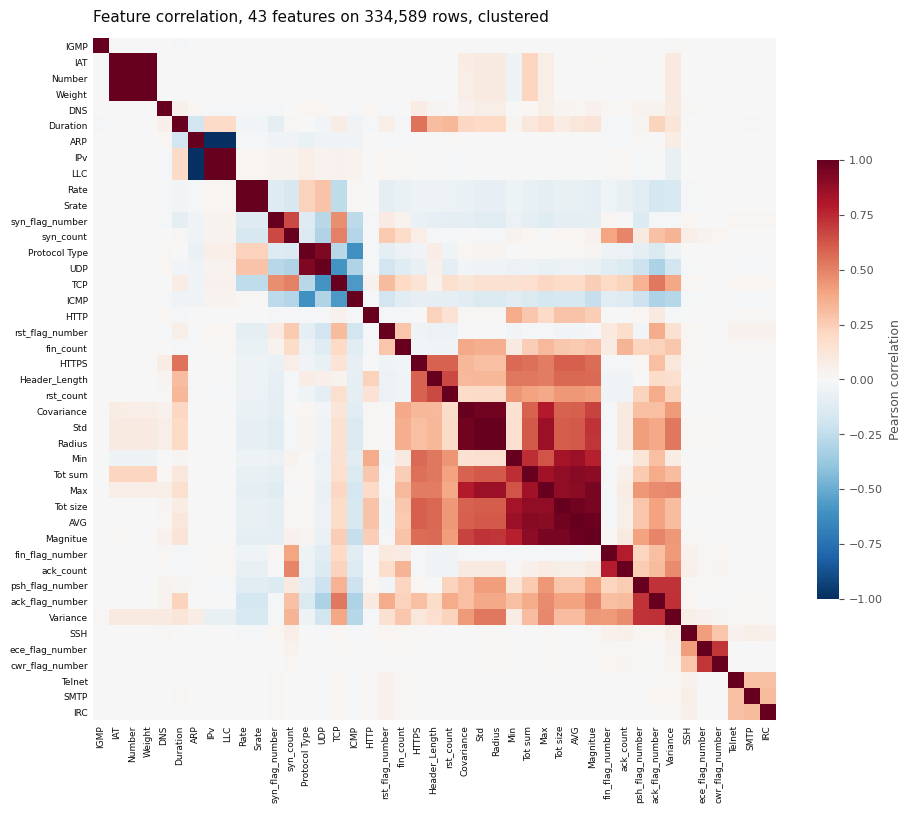

In [40]:
CORR = eda.correlation(SAMPLE, FEATURES)
CORR_ORDER = eda.cluster_order(CORR)
ordered = CORR.loc[CORR_ORDER, CORR_ORDER]

fig, ax = plt.subplots(figsize=(11, 9.5))
image = ax.imshow(ordered.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_ORDER)))
ax.set_yticks(range(len(CORR_ORDER)))
ax.set_xticklabels(CORR_ORDER, rotation=90, fontsize=6.5, color=INK)
ax.set_yticklabels(CORR_ORDER, fontsize=6.5, color=INK)
ax.tick_params(length=0)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title(
    f"Feature correlation, {len(FEATURES)} features on {len(SAMPLE):,} rows, clustered",
    color=INK,
    fontsize=11,
    loc="left",
    pad=12,
)
bar = fig.colorbar(image, ax=ax, shrink=0.6)
bar.set_label("Pearson correlation", color=MUTED, fontsize=9)
bar.ax.tick_params(colors=MUTED, labelsize=8)
bar.outline.set_visible(False)

FIG_CORR = save_figure(fig, "NB03_feature_correlation_clustered.png")

In [41]:
HIGH_CORR = eda.high_correlation_pairs(CORR, CORRELATION_FLAG)

print(f"pairs at or above {CORRELATION_FLAG} absolute correlation: {len(HIGH_CORR)}")
print()
if len(HIGH_CORR):
    for _, row in HIGH_CORR.iterrows():
        fa, fb = row["feature_a"], row["feature_b"]
        print(f"  {fa:<18} {fb:<18} r = {row['correlation']:+.4f}   ({FAMILY_OF.get(fa)} / {FAMILY_OF.get(fb)})")
    involved = sorted(set(HIGH_CORR["feature_a"]) | set(HIGH_CORR["feature_b"]))
    print()
    print(f"{len(involved)} of {len(FEATURES)} features appear in at least one such pair:")
    print("  " + ", ".join(involved))
else:
    print("  none")

missing_corr = CORR.columns[CORR.isna().all()].tolist()
if missing_corr:
    print()
    print(f"no correlation could be computed for {missing_corr}; they hold one value in the kept rows")

pairs at or above 0.95 absolute correlation: 14

  Rate               Srate              r = +1.0000   (timing / timing)
  IPv                LLC                r = +1.0000   (protocol / protocol)
  ARP                IPv                r = -1.0000   (protocol / protocol)
  ARP                LLC                r = -1.0000   (protocol / protocol)
  Std                Radius             r = +1.0000   (statistical / statistical)
  Number             Weight             r = +0.9999   (statistical / statistical)
  IAT                Weight             r = +0.9986   (timing / statistical)
  IAT                Number             r = +0.9982   (timing / statistical)
  AVG                Magnitue           r = +0.9802   (statistical / statistical)
  AVG                Tot size           r = +0.9683   (statistical / statistical)
  Radius             Covariance         r = +0.9679   (statistical / statistical)
  Std                Covariance         r = +0.9678   (statistical / statistical)
  Max

## Step 4 — the timing features against the rest

NB04 in this repository asked whether the features identify the recording a row came from
rather than the attack it represents, and found that they do: `Duration`, `Rate`, `Srate`
and `IAT` on their own name which of fifty recordings a row came from with 0.94 accuracy
against a chance rate of 0.02. Those four are plotted first, by 6-class category, because
if a feature carries the identity of a session then its distribution should sit in a
visibly different place for each category and the separation should look almost too clean.

Then four features from the other two families for contrast. If the timing panels are
sharply separated and these are not, that is the same finding drawn rather than fitted.

The axis is symmetric log wherever the largest value of a feature sits more than a thousand
times above its typical one, which is most of the timing features. It is symmetric rather
than plain log because most of these features take the value zero often, and a plain log
axis drops those rows without saying so. Whiskers run to the 1st and 99th percentile.

features plotted, and the family each sits in
  Duration         timing       carries capture identity by the NB04 result
  Rate             timing       carries capture identity by the NB04 result
  Srate            timing       carries capture identity by the NB04 result
  IAT              timing       carries capture identity by the NB04 result
  Protocol Type    protocol     contrast
  syn_count        protocol     contrast
  Tot size         statistical  contrast
  Magnitue         statistical  contrast
wrote NB03_distribution_timing_features.png   247 kB


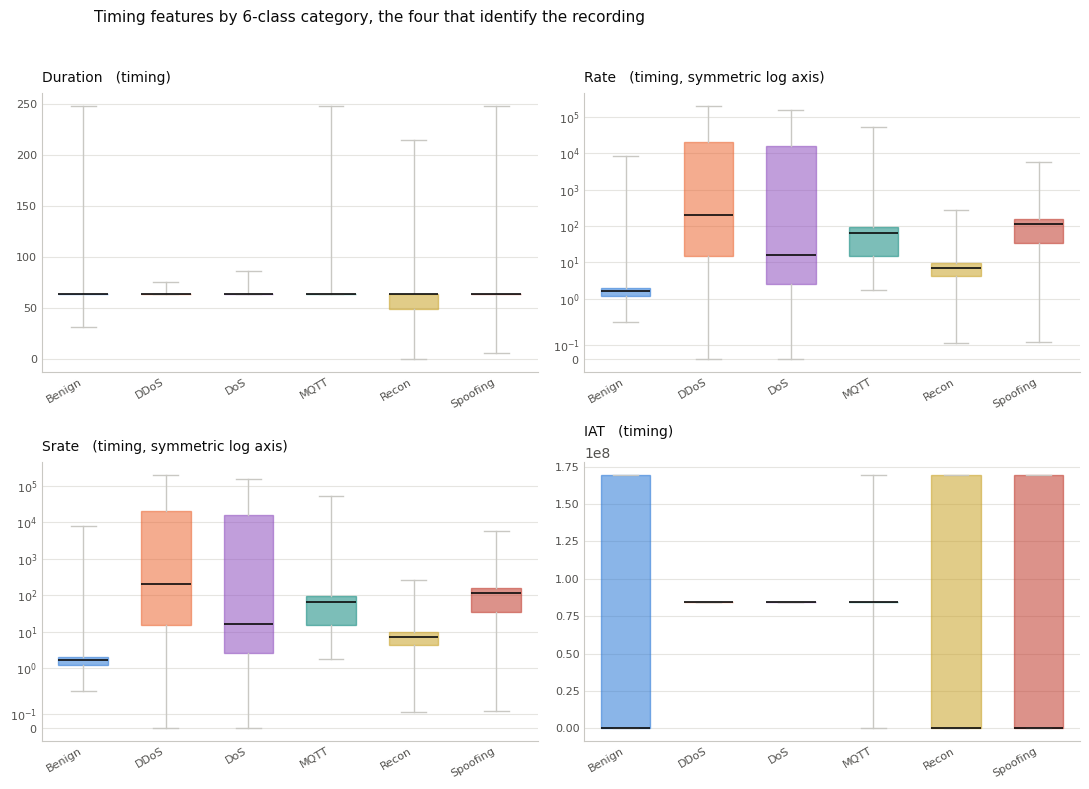

In [42]:
CAPTURE_IDENTITY_FEATURES = ["Duration", "Rate", "Srate", "IAT"]
CONTRAST_FEATURES = ["Protocol Type", "syn_count", "Tot size", "Magnitue"]

for name in CAPTURE_IDENTITY_FEATURES + CONTRAST_FEATURES:
    assert name in FEATURES, f"{name} is not among the features"

print("features plotted, and the family each sits in")
for name in CAPTURE_IDENTITY_FEATURES:
    print(f"  {name:<16} {FAMILY_OF.get(name):<12} carries capture identity by the NB04 result")
for name in CONTRAST_FEATURES:
    print(f"  {name:<16} {FAMILY_OF.get(name):<12} contrast")


def distribution_panel(ax, feature, title):
    groups = [SAMPLE.loc[SAMPLE["__group6"] == g, feature].to_numpy() for g in GROUP6_ORDER]
    box = ax.boxplot(
        groups,
        vert=True,
        whis=(1, 99),
        showfliers=False,
        patch_artist=True,
        widths=0.6,
        medianprops={"color": INK, "linewidth": 1.2},
    )
    for patch, group in zip(box["boxes"], GROUP6_ORDER):
        patch.set_facecolor(GROUP_COLOUR[group])
        patch.set_alpha(0.55)
        patch.set_edgecolor(GROUP_COLOUR[group])
    for element in ("whiskers", "caps"):
        for line in box[element]:
            line.set_color(RULE)

    needs_log, linthresh = eda.log_axis(SAMPLE[feature].to_numpy())
    if needs_log:
        ax.set_yscale("symlog", linthresh=linthresh)
    ax.set_xticks(range(1, len(GROUP6_ORDER) + 1))
    ax.set_xticklabels(GROUP6_ORDER, rotation=30, ha="right")
    ax.set_title(
        f"{feature}   ({FAMILY_OF.get(feature)}{', symmetric log axis' if needs_log else ''})",
        color=INK,
        fontsize=10,
        loc="left",
        pad=8,
    )
    style(ax)
    return needs_log


def distribution_figure(features, heading, filename):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, feature in zip(axes.ravel(), features):
        distribution_panel(ax, feature, heading)
    fig.suptitle(heading, color=INK, fontsize=11, x=0.09, ha="left", y=0.98)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return save_figure(fig, filename)


FIG_TIMING = distribution_figure(
    CAPTURE_IDENTITY_FEATURES,
    "Timing features by 6-class category, the four that identify the recording",
    "NB03_distribution_timing_features.png",
)

wrote NB03_distribution_protocol_statistical.png   233 kB


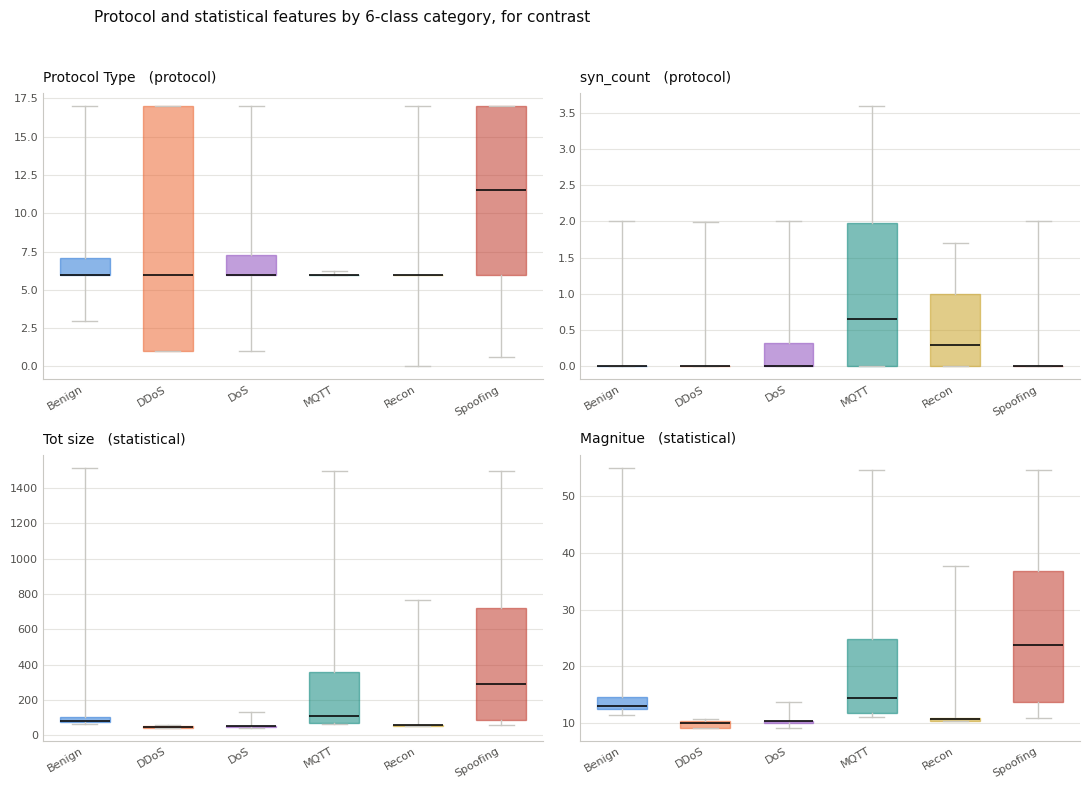

In [43]:
FIG_CONTRAST = distribution_figure(
    CONTRAST_FEATURES,
    "Protocol and statistical features by 6-class category, for contrast",
    "NB03_distribution_protocol_statistical.png",
)

The medians behind those panels, printed so the separation can be read as numbers rather
than judged by eye. A feature whose median differs by orders of magnitude between
categories is one a single threshold would already split.

In [44]:
panel_features = CAPTURE_IDENTITY_FEATURES + CONTRAST_FEATURES
medians_by_group = (
    SAMPLE.groupby("__group6")[panel_features].median().reindex(GROUP6_ORDER).T
)
medians_by_group["max_over_min"] = medians_by_group.replace(0, np.nan).max(axis=1) / medians_by_group.replace(
    0, np.nan
).min(axis=1)

print("median of each feature within each 6-class category")
print()
print(medians_by_group.to_string(float_format=lambda v: f"{v:,.4g}"))
print()
print("the last column is the largest median over the smallest, ignoring zeros")

median of each feature within each 6-class category

__group6       Benign     DDoS       DoS      MQTT  Recon  Spoofing  max_over_min
Duration           64       64        64        64     64        64             1
Rate            1.667    196.6     16.28     64.99  6.883     112.4         117.9
Srate           1.667    196.6     16.28     64.99  6.883     112.4         117.9
IAT            0.1006 8.47e+07 8.467e+07 8.467e+07  0.232    0.1008      8.42e+08
Protocol Type       6        6         6         6      6      11.5         1.917
syn_count           0        0         0      0.65    0.3         0         2.167
Tot size         81.2       50        54     110.7     58     290.3         5.806
Magnitue           13       10     10.39     14.43  10.77     23.83         2.383

the last column is the largest median over the smallest, ignoring zeros


## Step 5 — what one feature knows about the class

Mutual information measures how much knowing a feature reduces uncertainty about the label.
It is computed one feature at a time, so it says what a column knows on its own and nothing
about what two of them know together. Zero means the feature and the label are independent;
there is no upper bound that makes the numbers comparable across different label sets, so
the two rankings below are compared by order rather than by value.

The estimator reads whatever class distribution it is given, and the largest class here
holds a fifth of the corpus while the smallest holds a five-hundredth of it. Left alone it
would report how well each feature detects the two or three largest classes. So it gets an
equal draw of rows from every class instead.

In [45]:
mi_positions = eda.balanced_draw(SAMPLE["__label"].to_numpy(), MI_ROWS_PER_CLASS, RNG)
MI_FRAME = SAMPLE.iloc[mi_positions].reset_index(drop=True)

counts = MI_FRAME["__label"].value_counts()
short = counts[counts < MI_ROWS_PER_CLASS]

print(f"{len(MI_FRAME):,} rows, {MI_FRAME['__label'].nunique()} classes, asked for {MI_ROWS_PER_CLASS:,} per class")
if len(short):
    print()
    print("classes with fewer rows available than that:")
    print(short.to_string())
print()
print(f"estimating mutual information for {len(FEATURES)} features against the 19-class label")

started = time.perf_counter()
MI_19 = eda.mutual_information(
    MI_FRAME[FEATURES].to_numpy(dtype="float64"),
    MI_FRAME["__label"].to_numpy(),
    FEATURES,
    seed=SEED,
)
MI_19["family"] = MI_19["feature"].map(FAMILY_OF)
print(f"took {time.perf_counter() - started:,.0f}s")
print()
print(MI_19.head(20).to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

36,926 rows, 19 classes, asked for 2,000 per class

classes with fewer rows available than that:
__label
Recon-Ping_Sweep    926

estimating mutual information for 43 features against the 19-class label
took 13s

 rank         feature  mutual_information      family
    1             IAT              2.6074      timing
    2         Tot sum              1.7024 statistical
    3        Tot size              1.6710 statistical
    4             Min              1.5931 statistical
    5             Max              1.5850 statistical
    6        Magnitue              1.5535 statistical
    7             AVG              1.5486 statistical
    8   Header_Length              1.4358    protocol
    9            Rate              1.3110      timing
   10           Srate              1.3109      timing
   11       rst_count              1.1261    protocol
   12   Protocol Type              0.8368    protocol
   13          Radius              0.8336 statistical
   14             Std          

wrote NB03_mutual_information_top20.png   212 kB


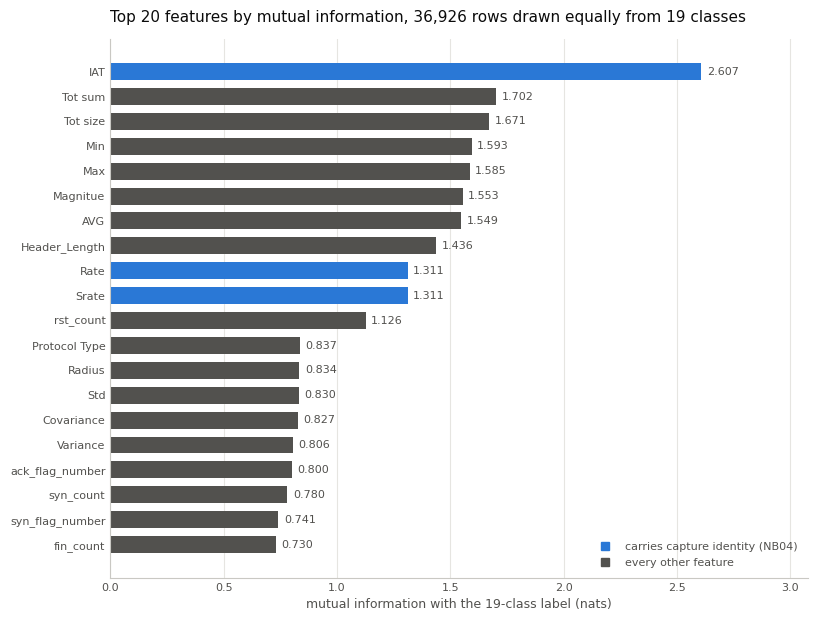

In [46]:
fig, ax = plt.subplots(figsize=(9, 7))
top20 = MI_19.head(20).iloc[::-1]
bars = ax.barh(
    top20["feature"],
    top20["mutual_information"],
    color=[GROUP_COLOUR["Benign"] if f in CAPTURE_IDENTITY_FEATURES else MUTED for f in top20["feature"]],
    height=0.68,
)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in top20["mutual_information"]], padding=4, color=MUTED, fontsize=8)
ax.set_xlim(right=top20["mutual_information"].max() * 1.18)
ax.set_xlabel("mutual information with the 19-class label (nats)", color=MUTED, fontsize=9)
ax.set_title(
    f"Top 20 features by mutual information, {len(MI_FRAME):,} rows drawn equally from 19 classes",
    color=INK,
    fontsize=11,
    loc="left",
    pad=12,
)
style(ax, grid_axis="x")
handles = [
    Line2D([], [], marker="s", linestyle="none", color=GROUP_COLOUR["Benign"], label="carries capture identity (NB04)"),
    Line2D([], [], marker="s", linestyle="none", color=MUTED, label="every other feature"),
]
legend = ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(MUTED)

FIG_MI = save_figure(fig, "NB03_mutual_information_top20.png")

The same measurement against a different question. This project fixed four target classes
in advance, and a feature that ranks highly across all nineteen classes is not necessarily
a feature that helps with those four. The label here keeps the four apart from each other
and pools every other class into one, so a feature scores well only if it distinguishes the
targets from the rest and from each other. Pooling the four into a single positive set was
the other option and it was not taken, because the four have very little in common and a
feature separating one of them would be credited for all four.

The rows for the pooled class come from the balanced draw above, so it is itself an even
mixture of the other fifteen classes rather than being dominated by the largest of them.

In [47]:
is_target = MI_FRAME["__label"].isin(TARGET_CLASSES)
other_positions = np.flatnonzero(~is_target.to_numpy())
if len(other_positions) > MI_ROWS_PER_CLASS:
    other_positions = np.sort(RNG.choice(other_positions, size=MI_ROWS_PER_CLASS, replace=False))

TARGET_FRAME = MI_FRAME.iloc[np.sort(np.concatenate([np.flatnonzero(is_target.to_numpy()), other_positions]))]
target_label = np.where(TARGET_FRAME["__label"].isin(TARGET_CLASSES), TARGET_FRAME["__label"], "Other")

print("rows per level of the target label")
print(pd.Series(target_label).value_counts().to_string())
print()
print(f"estimating mutual information for {len(FEATURES)} features against that label")

started = time.perf_counter()
MI_TARGET = eda.mutual_information(
    TARGET_FRAME[FEATURES].to_numpy(dtype="float64"),
    target_label,
    FEATURES,
    seed=SEED,
)
MI_TARGET["family"] = MI_TARGET["feature"].map(FAMILY_OF)
print(f"took {time.perf_counter() - started:,.0f}s")
print()
print(MI_TARGET.head(20).to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

rows per level of the target label
Spoofing                   2000
Other                      2000
MQTT-DDoS-Publish_Flood    2000
Recon-OS_Scan              2000
Recon-VulScan              2000

estimating mutual information for 43 features against that label
took 2s

 rank         feature  mutual_information      family
    1             IAT              1.2043      timing
    2           Srate              0.7041      timing
    3            Rate              0.7035      timing
    4             Max              0.6853 statistical
    5         Tot sum              0.6549 statistical
    6             Min              0.6478 statistical
    7        Tot size              0.6422 statistical
    8   Header_Length              0.6225    protocol
    9             AVG              0.5863 statistical
   10        Magnitue              0.5844 statistical
   11          Number              0.5401 statistical
   12          Weight              0.5343 statistical
   13        Variance       

In [48]:
COMPARISON = eda.compare_rankings(MI_19, MI_TARGET, left_name="all19", right_name="target5")
COMPARISON["family"] = COMPARISON["feature"].map(FAMILY_OF)

side_by_side = pd.DataFrame(
    {
        "rank": range(1, 21),
        "all 19 classes": MI_19.head(20)["feature"].to_numpy(),
        "mi": MI_19.head(20)["mutual_information"].round(4).to_numpy(),
        "four targets against the rest": MI_TARGET.head(20)["feature"].to_numpy(),
        "mi ": MI_TARGET.head(20)["mutual_information"].round(4).to_numpy(),
    }
)

print("top 20 by each ranking")
print()
print(side_by_side.to_string(index=False))
print()

in_19 = set(MI_19.head(20)["feature"])
in_target = set(MI_TARGET.head(20)["feature"])
print(f"in both top 20s      : {len(in_19 & in_target)} features")
print(f"only for all 19      : {', '.join(sorted(in_19 - in_target)) or 'none'}")
print(f"only for the targets : {', '.join(sorted(in_target - in_19)) or 'none'}")
print()

movers = COMPARISON.reindex(COMPARISON["rank_change"].abs().sort_values(ascending=False).index).head(10)
print("ten features whose rank moves most between the two questions")
print("a positive change means the feature matters more for the four target classes")
print()
print(
    movers[["feature", "family", "rank_all19", "rank_target5", "rank_change", "mi_all19", "mi_target5"]].to_string(
        index=False, float_format=lambda v: f"{v:,.4f}"
    )
)

top 20 by each ranking

 rank  all 19 classes     mi four targets against the rest    mi 
    1             IAT 2.6074                           IAT 1.2043
    2         Tot sum 1.7024                         Srate 0.7041
    3        Tot size 1.6710                          Rate 0.7035
    4             Min 1.5931                           Max 0.6853
    5             Max 1.5850                       Tot sum 0.6549
    6        Magnitue 1.5535                           Min 0.6478
    7             AVG 1.5486                      Tot size 0.6422
    8   Header_Length 1.4358                 Header_Length 0.6225
    9            Rate 1.3110                           AVG 0.5863
   10           Srate 1.3109                      Magnitue 0.5844
   11       rst_count 1.1261                        Number 0.5401
   12   Protocol Type 0.8368                        Weight 0.5343
   13          Radius 0.8336                      Variance 0.5226
   14             Std 0.8302                     rst

wrote NB03_mutual_information_target_classes_top20.png   318 kB


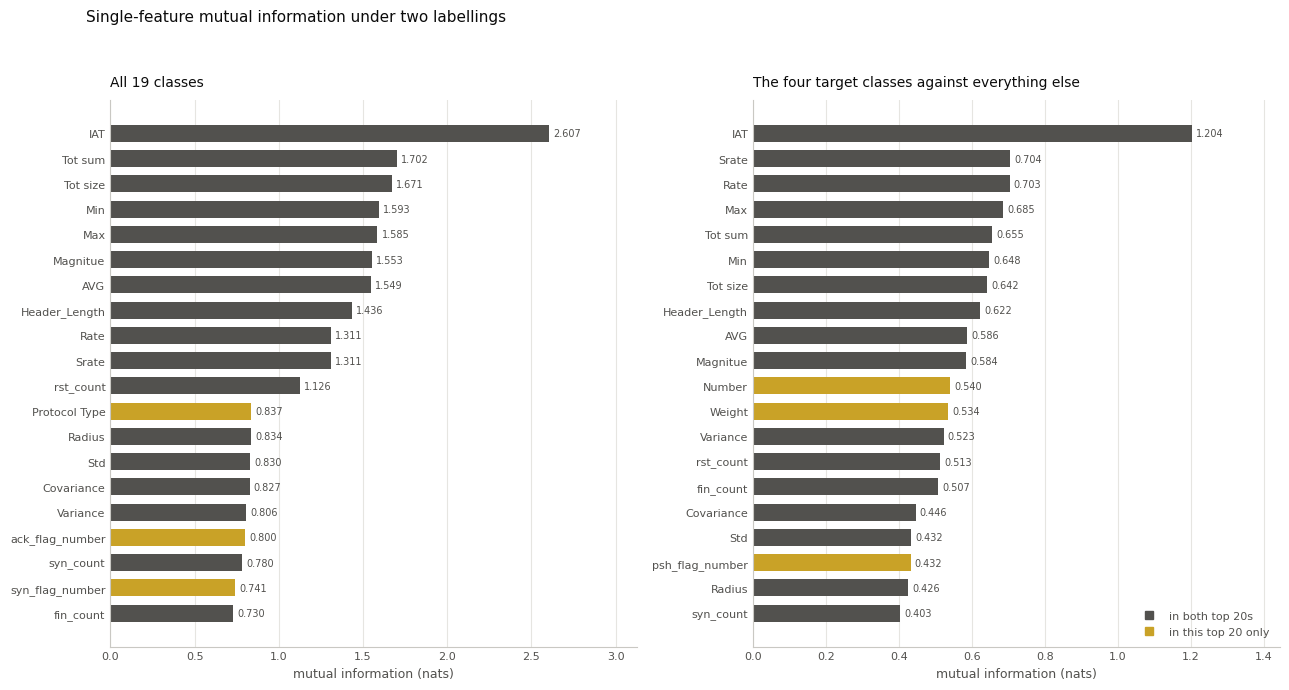

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharex=False)
for ax, ranking, heading in zip(
    axes,
    (MI_19, MI_TARGET),
    ("All 19 classes", "The four target classes against everything else"),
):
    top = ranking.head(20).iloc[::-1]
    moved_up = [
        f in set(MI_TARGET.head(20)["feature"]) and f in set(MI_19.head(20)["feature"]) for f in top["feature"]
    ]
    bars = ax.barh(
        top["feature"],
        top["mutual_information"],
        color=[MUTED if both else GROUP_COLOUR["Recon"] for both in moved_up],
        height=0.68,
    )
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in top["mutual_information"]], padding=3, color=MUTED, fontsize=7)
    ax.set_xlim(right=top["mutual_information"].max() * 1.2)
    ax.set_xlabel("mutual information (nats)", color=MUTED, fontsize=9)
    ax.set_title(heading, color=INK, fontsize=10, loc="left", pad=10)
    style(ax, grid_axis="x")

handles = [
    Line2D([], [], marker="s", linestyle="none", color=MUTED, label="in both top 20s"),
    Line2D([], [], marker="s", linestyle="none", color=GROUP_COLOUR["Recon"], label="in this top 20 only"),
]
legend = axes[1].legend(handles=handles, loc="lower right", frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(MUTED)
fig.suptitle("Single-feature mutual information under two labellings", color=INK, fontsize=11, x=0.07, ha="left", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.95))

FIG_MI_TARGET = save_figure(fig, "NB03_mutual_information_target_classes_top20.png")

## Step 6 — does the strongest feature move between recordings of the same attack

A feature can rank highly in step 5 for two different reasons. It can differ between
attacks, which is what a feature is supposed to do, or it can differ between recording
sessions, and because each session holds exactly one class those two look identical in any
measurement taken over the pooled rows.

Telling them apart needs the captures kept separate. Each point below is the mean of one
feature inside one recording, and the bar around it is the standard deviation of that
feature inside the same recording. The recordings are grouped by class. A feature that
differs between attacks shows points that cluster tightly within each class and sit apart
between classes. A feature that carries the session shows points that scatter within a
class, and the classes recorded several times are where that is visible, since a class
recorded once contributes a single point and can say nothing either way.

The means come from every row that was read, not from the kept rows, because they were
computed while each file was open.

61 recordings across 19 classes
classes with more than one recording: 8

top 10 features by mutual information, plotted below
IAT, Tot sum, Tot size, Min, Max, Magnitue, AVG, Header_Length, Rate, Srate
wrote NB03_between_capture_variation_top10.png   786 kB


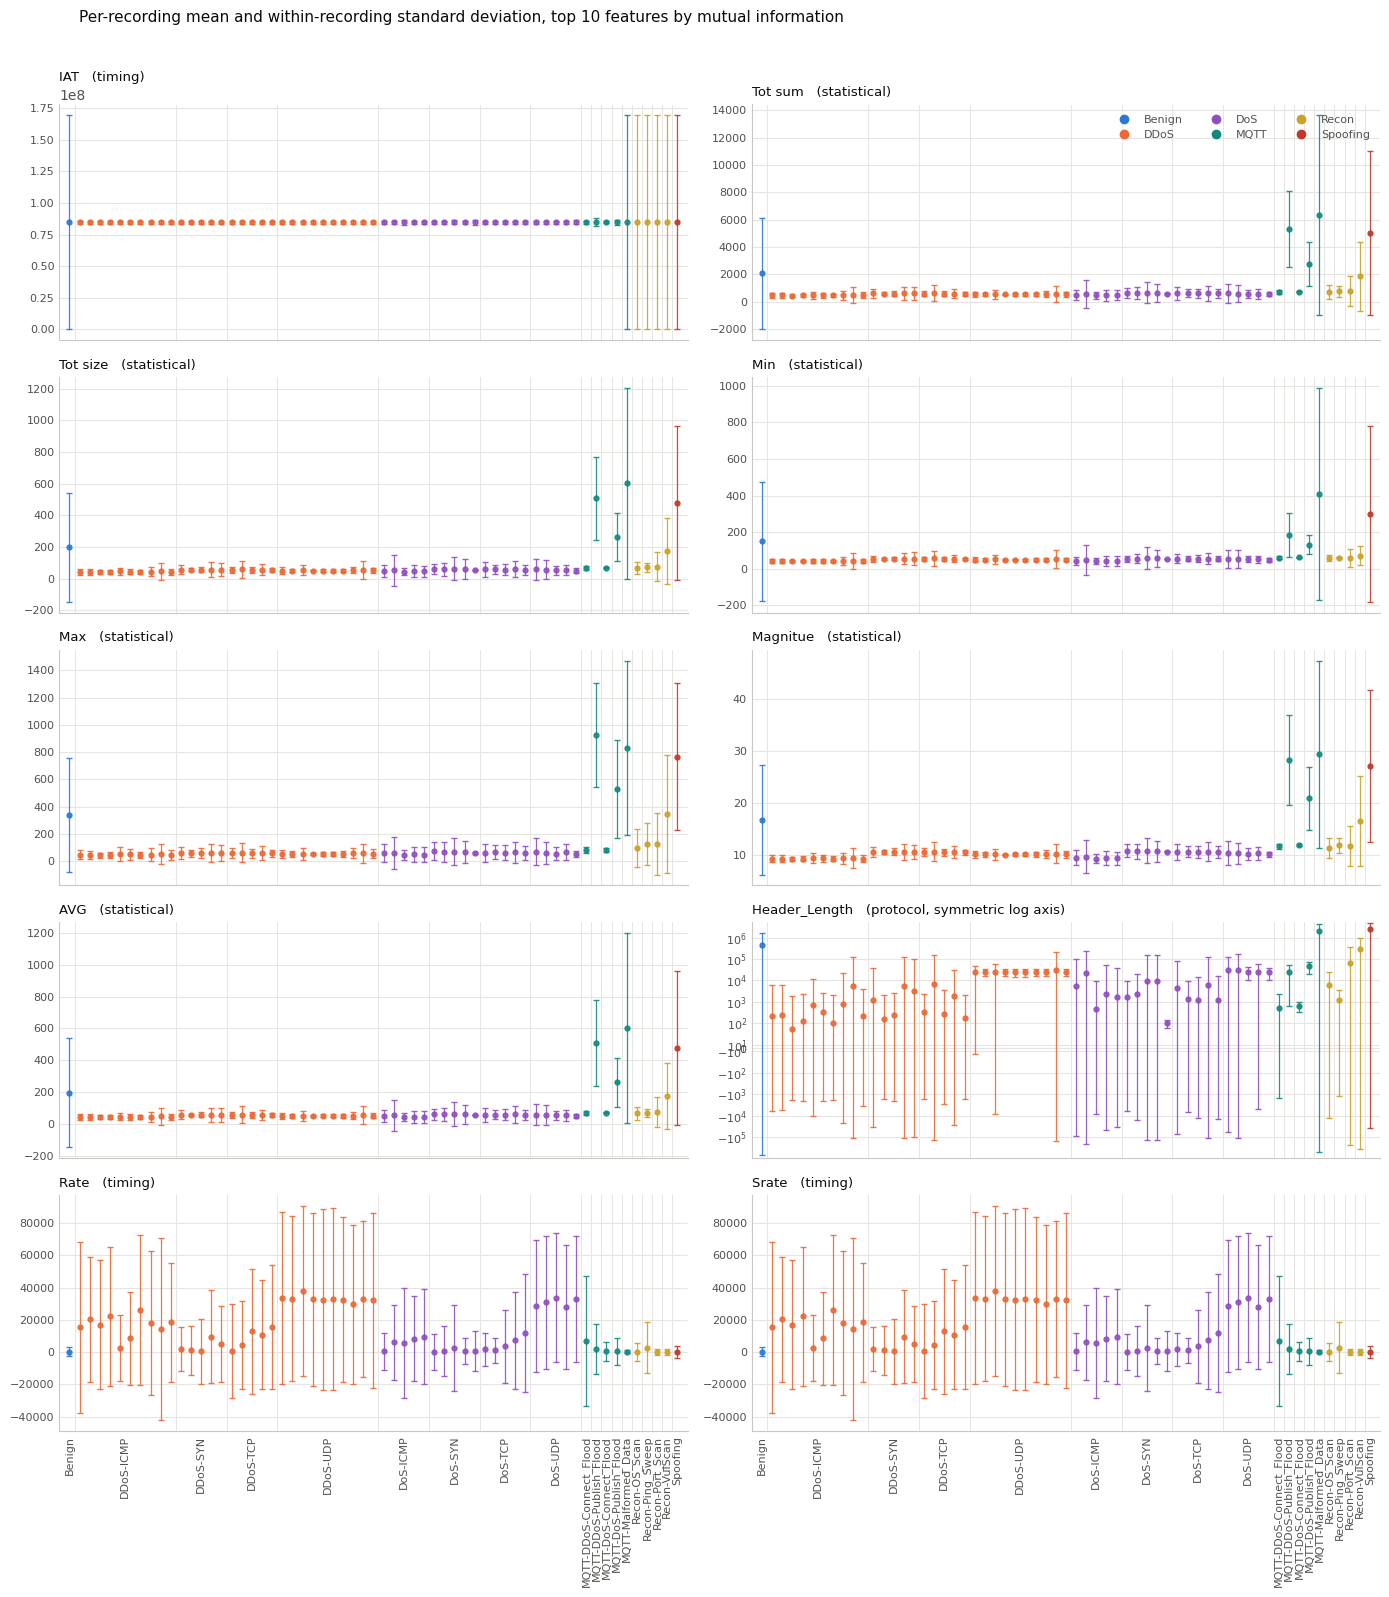

In [50]:
POOLED = leak.pool_moments(MOMENTS, by="capture")
POOLED["label"] = POOLED["capture"].map(CAPTURE_LABEL)
POOLED["group6"] = POOLED["capture"].map(CAPTURE_GROUP6)
POOLED["sd"] = np.sqrt(POOLED["var"].clip(lower=0))

TOP_MI = MI_19.head(10)["feature"].tolist()

capture_order = (
    POOLED.drop_duplicates("capture")[["capture", "label", "group6"]]
    .sort_values(["group6", "label", "capture"])
    .reset_index(drop=True)
)
capture_order["x"] = np.arange(len(capture_order))
POSITION = capture_order.set_index("capture")["x"]

recordings_per_class = capture_order.groupby("label").size()
print(f"{len(capture_order)} recordings across {capture_order['label'].nunique()} classes")
print(f"classes with more than one recording: {int((recordings_per_class > 1).sum())}")
print()
print("top 10 features by mutual information, plotted below")
print(", ".join(TOP_MI))


def capture_panel(ax, feature, *, with_labels):
    frame = POOLED.loc[POOLED["feature"] == feature].copy()
    frame["x"] = frame["capture"].map(POSITION)
    frame = frame.sort_values("x")
    for group, part in frame.groupby("group6"):
        ax.errorbar(
            part["x"],
            part["mean"],
            yerr=part["sd"],
            fmt="o",
            markersize=3.5,
            elinewidth=0.9,
            capsize=2,
            color=GROUP_COLOUR[group],
            ecolor=GROUP_COLOUR[group],
            alpha=0.9,
            linestyle="none",
        )
    boundaries = capture_order.groupby("label")["x"].max().sort_values().to_numpy()[:-1]
    for edge in boundaries:
        ax.axvline(edge + 0.5, color=GRID, linewidth=0.7)

    needs_log, linthresh = eda.log_axis(frame["mean"].to_numpy())
    if needs_log:
        ax.set_yscale("symlog", linthresh=linthresh)
    ax.set_title(
        f"{feature}   ({FAMILY_OF.get(feature)}{', symmetric log axis' if needs_log else ''})",
        color=INK,
        fontsize=9.5,
        loc="left",
        pad=6,
    )
    ax.set_xlim(-1, len(capture_order))
    if with_labels:
        centres = capture_order.groupby("label")["x"].mean().sort_values()
        ax.set_xticks(centres.to_numpy())
        ax.set_xticklabels(centres.index, rotation=90, fontsize=6.5)
    else:
        ax.set_xticks([])
    style(ax)


fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)
for i, (ax, feature) in enumerate(zip(axes.ravel(), TOP_MI)):
    capture_panel(ax, feature, with_labels=i >= len(TOP_MI) - 2)
group_legend(axes[0, 1], loc="upper right", ncol=3)
fig.suptitle(
    "Per-recording mean and within-recording standard deviation, top 10 features by mutual information",
    color=INK,
    fontsize=11,
    x=0.06,
    ha="left",
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.985))

FIG_CAPTURE_GRID = save_figure(fig, "NB03_between_capture_variation_top10.png")

In [51]:
for rank, feature in enumerate(TOP_MI, start=1):
    fig, ax = plt.subplots(figsize=(12, 4))
    capture_panel(ax, feature, with_labels=True)
    group_legend(ax, loc="upper right", ncol=3)
    fig.tight_layout()
    save_figure(fig, f"NB03_capture_means_{rank:02d}_{feature.replace(' ', '_')}.png", show=False)

wrote NB03_capture_means_01_IAT.png   190 kB
wrote NB03_capture_means_02_Tot_sum.png   203 kB
wrote NB03_capture_means_03_Tot_size.png   202 kB
wrote NB03_capture_means_04_Min.png   200 kB
wrote NB03_capture_means_05_Max.png   199 kB
wrote NB03_capture_means_06_Magnitue.png   196 kB
wrote NB03_capture_means_07_AVG.png   203 kB
wrote NB03_capture_means_08_Header_Length.png   235 kB
wrote NB03_capture_means_09_Rate.png   230 kB
wrote NB03_capture_means_10_Srate.png   231 kB


The same thing as numbers. For each of the ten features and each class recorded more than
once, the spread of the per-recording means is compared with the typical spread inside one
recording. A ratio above one means the feature moves further between recordings of the same
attack than it moves inside a single recording of it.

In [52]:
rows = []
for feature in TOP_MI:
    frame = POOLED.loc[POOLED["feature"] == feature]
    for label, part in frame.groupby("label"):
        if len(part) < 2:
            continue
        within = float(np.sqrt(part["var"].clip(lower=0).mean()))
        between = float(part["mean"].std(ddof=0))
        rows.append(
            {
                "feature": feature,
                "class": label,
                "recordings": len(part),
                "between_recording_sd": between,
                "within_recording_sd": within,
                "ratio": between / within if within > 0 else np.inf,
            }
        )

BETWEEN_CAPTURE = pd.DataFrame(rows)
per_feature = (
    BETWEEN_CAPTURE.replace(np.inf, np.nan)
    .groupby("feature")
    .agg(
        classes=("class", "size"),
        median_ratio=("ratio", "median"),
        max_ratio=("ratio", "max"),
        classes_above_1=("ratio", lambda s: int((s > 1).sum())),
    )
    .reindex(TOP_MI)
)

print("spread of per-recording means over spread inside a recording, within one class")
print()
print(per_feature.to_string(float_format=lambda v: f"{v:,.3f}"))
print()
print("the five widest single cases")
print(
    BETWEEN_CAPTURE.replace(np.inf, np.nan)
    .sort_values("ratio", ascending=False)
    .head(5)
    .to_string(index=False, float_format=lambda v: f"{v:,.4g}")
)

spread of per-recording means over spread inside a recording, within one class

               classes  median_ratio  max_ratio  classes_above_1
feature                                                         
IAT                  8         0.003      0.005                0
Tot sum              8         0.044      0.063                0
Tot size             8         0.044      0.063                0
Min                  8         0.036      0.059                0
Max                  8         0.072      0.091                0
Magnitue             8         0.047      0.068                0
AVG                  8         0.043      0.062                0
Header_Length        8         0.039      0.075                0
Rate                 8         0.137      0.166                0
Srate                8         0.137      0.166                0

the five widest single cases
feature    class  recordings  between_recording_sd  within_recording_sd  ratio
  Srate  DoS-TCP           5   

## Step 7 — which classes no single feature can tell apart

The last question is about pairs of classes rather than about features. For each of the 171
pairs among the nineteen classes, every feature is scored by the area under its ROC curve
on that pair alone, and the best of the 43 is kept. A pair at 1.0 has some feature that
splits it perfectly with a single threshold. A pair at 0.5 has no feature that separates it
at all, and any model getting that pair right has to be combining features.

The AUC is taken as the larger of the value and one minus it, because a feature that
separates two classes perfectly in the wrong direction separates them perfectly. Half is
therefore the floor rather than the middle.

Each class contributes an equal number of rows, so a pair involving a large class is not
scored more precisely than a pair of two small ones.

In [53]:
auc_positions = eda.balanced_draw(SAMPLE["__label"].to_numpy(), AUC_ROWS_PER_CLASS, RNG)
AUC_FRAME = SAMPLE.iloc[auc_positions]

print(f"{len(AUC_FRAME):,} rows, asked for {AUC_ROWS_PER_CLASS:,} per class")
counts = AUC_FRAME["__label"].value_counts()
short = counts[counts < AUC_ROWS_PER_CLASS]
if len(short):
    print()
    print("classes with fewer rows available:")
    print(short.to_string())
print()
n_pairs = len(CLASS_ORDER) * (len(CLASS_ORDER) - 1) // 2
print(f"scoring {len(FEATURES)} features on each of {n_pairs} class pairs")

started = time.perf_counter()
AUC_MATRIX, AUC_PAIRS = eda.pairwise_best_auc(
    AUC_FRAME[FEATURES].to_numpy(dtype="float64"),
    AUC_FRAME["__label"].to_numpy(),
    FEATURES,
    class_order=CLASS_ORDER,
)
print(f"took {time.perf_counter() - started:,.0f}s")
print()
print(f"best single-feature AUC over all pairs : median {AUC_PAIRS['best_auc'].median():.4f}, "
      f"lowest {AUC_PAIRS['best_auc'].min():.4f}, highest {AUC_PAIRS['best_auc'].max():.4f}")
print(f"pairs separable by one feature at {SEPARABLE_AUC}: "
      f"{int((AUC_PAIRS['best_auc'] >= SEPARABLE_AUC).sum())} of {len(AUC_PAIRS)}")

36,926 rows, asked for 2,000 per class

classes with fewer rows available:
__label
Recon-Ping_Sweep    926

scoring 43 features on each of 171 class pairs
took 2s

best single-feature AUC over all pairs : median 0.9987, lowest 0.6585, highest 1.0000
pairs separable by one feature at 0.9: 160 of 171


wrote NB03_class_separability_best_single_feature_auc.png   439 kB


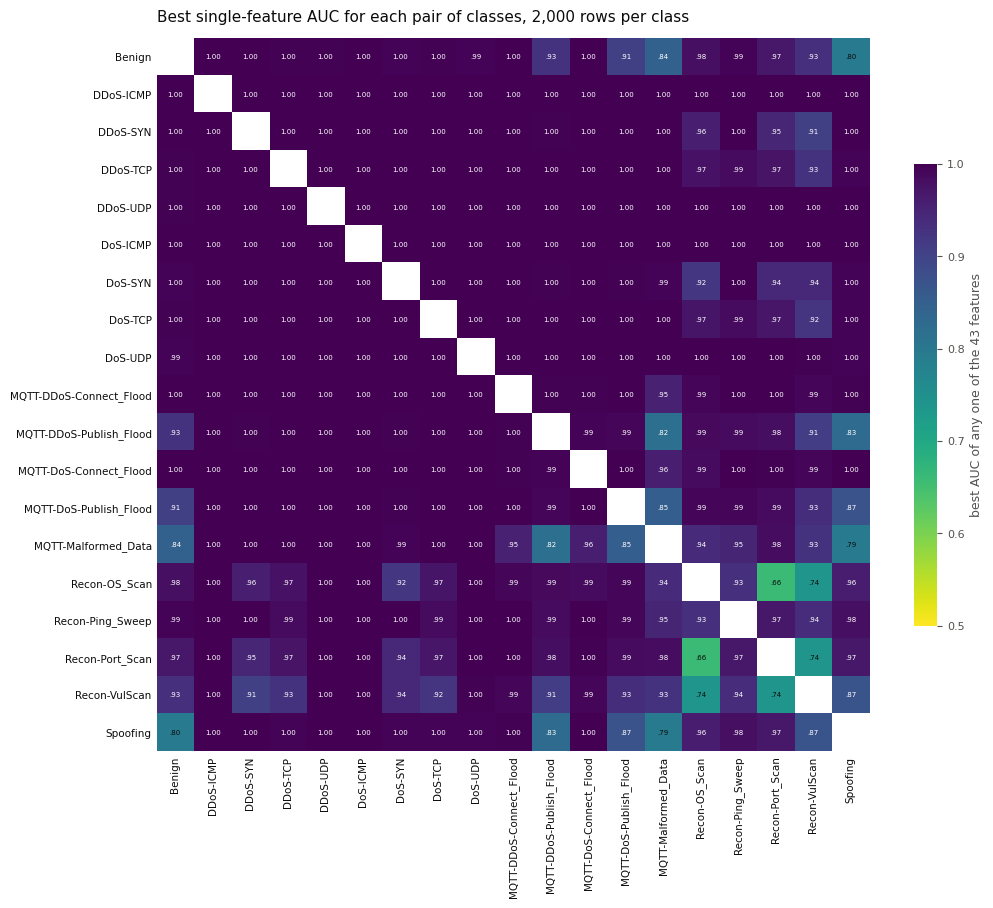

In [54]:
fig, ax = plt.subplots(figsize=(11.5, 10))
values = AUC_MATRIX.to_numpy().copy()
np.fill_diagonal(values, np.nan)
image = ax.imshow(values, cmap="viridis_r", vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=90, fontsize=7.5, color=INK)
ax.set_yticklabels(CLASS_ORDER, fontsize=7.5, color=INK)
ax.tick_params(length=0)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        if i == j:
            continue
        value = values[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}".lstrip("0"),
            ha="center",
            va="center",
            fontsize=5,
            color="white" if value > 0.8 else INK,
        )

ax.set_title(
    f"Best single-feature AUC for each pair of classes, {AUC_ROWS_PER_CLASS:,} rows per class",
    color=INK,
    fontsize=11,
    loc="left",
    pad=12,
)
bar = fig.colorbar(image, ax=ax, shrink=0.6)
bar.set_label("best AUC of any one of the 43 features", color=MUTED, fontsize=9)
bar.ax.tick_params(colors=MUTED, labelsize=8)
bar.outline.set_visible(False)

FIG_SEPARABILITY = save_figure(fig, "NB03_class_separability_best_single_feature_auc.png")

In [55]:
LEAST_SEPARABLE = AUC_PAIRS.head(10).copy()

print("the ten least separable pairs, and the best any single feature does on each")
print()
for i, row in enumerate(LEAST_SEPARABLE.itertuples(index=False), start=1):
    print(f"{i:>2}. {row.class_a:<26} {row.class_b:<26} AUC {row.best_auc:.4f}   {row.best_feature}")
    print(f"     next best {row.second_feature} at {row.second_auc:.4f}, {row.n_features_above_0_9} features above 0.9")
print()

involved = pd.concat([LEAST_SEPARABLE["class_a"], LEAST_SEPARABLE["class_b"]]).value_counts()
print("classes appearing in those ten pairs")
print(involved.to_string())
print()

target_rows = AUC_PAIRS[
    AUC_PAIRS["class_a"].isin(TARGET_CLASSES) | AUC_PAIRS["class_b"].isin(TARGET_CLASSES)
]
print("hardest pair for each of the four target classes")
for label in TARGET_CLASSES:
    rows = target_rows[(target_rows["class_a"] == label) | (target_rows["class_b"] == label)]
    worst = rows.iloc[0]
    other = worst["class_b"] if worst["class_a"] == label else worst["class_a"]
    print(f"  {label:<26} against {other:<26} AUC {worst['best_auc']:.4f} on {worst['best_feature']}")

the ten least separable pairs, and the best any single feature does on each

 1. Recon-OS_Scan              Recon-Port_Scan            AUC 0.6585   Rate
     next best Rate at 0.6585, 0 features above 0.9
 2. Recon-Port_Scan            Recon-VulScan              AUC 0.7394   Radius
     next best Covariance at 0.7388, 0 features above 0.9
 3. Recon-OS_Scan              Recon-VulScan              AUC 0.7395   Std
     next best Radius at 0.7394, 0 features above 0.9
 4. MQTT-Malformed_Data        Spoofing                   AUC 0.7934   TCP
     next best UDP at 0.7832, 0 features above 0.9
 5. Benign                     Spoofing                   AUC 0.7958   rst_count
     next best psh_flag_number at 0.7872, 0 features above 0.9
 6. MQTT-DDoS-Publish_Flood    MQTT-Malformed_Data        AUC 0.8182   HTTPS
     next best psh_flag_number at 0.8061, 0 features above 0.9
 7. MQTT-DDoS-Publish_Flood    Spoofing                   AUC 0.8256   psh_flag_number
     next best Header_Length at 0

Everything the notebook measured goes into one file: the summary of all 43 features, the
pairs that are near-duplicates of each other, both mutual information rankings, and the ten
class pairs no single feature separates. The figures are listed alongside it so that a
reader of the file knows which picture each number belongs to.

In [56]:
summary_doc = {
    "generated_by": "AG_PRAXIS_NB03_eda.ipynb",
    "generated_on": RUN_DATE,
    "git_sha": GIT_SHA,
    "fast_mode": FAST,
    "read_fraction": READ_FRAC,
    "seed": SEED,
    "rows_read": int(rows_read),
    "rows_in_corpus": int(sum(ROW_COUNTS.values())),
    "rows_dropped_non_finite": int(rows_dropped),
    "rows_kept_per_file": ROWS_PER_FILE,
    "rows_kept": int(len(SAMPLE)),
    "features_dropped": DROPPED,
    "n_features": len(FEATURES),
    "n_classes": int(files["label"].nunique()),
    "n_captures": int(files["capture"].nunique()),
    "thresholds": {
        "zero_share_flag": ZERO_SHARE_FLAG,
        "correlation_flag": CORRELATION_FLAG,
        "separable_auc": SEPARABLE_AUC,
        "fixed_before_running": True,
    },
    "feature_summary": [
        {
            "feature": row["feature"],
            "family": row["family"],
            "n": int(row["n"]),
            "mean": leak.json_number(row["mean"]),
            "std": leak.json_number(row["std"]),
            "min": leak.json_number(row["min"]),
            "median_of_kept_rows": leak.json_number(row["median"]),
            "max": leak.json_number(row["max"]),
            "skew": leak.json_number(row["skew"]) if pd.notna(row["skew"]) else None,
            "zero_share": leak.json_number(row["zero_share"]),
            "near_empty": bool(row["near_empty"]),
        }
        for _, row in SUMMARY.iterrows()
    ],
    "near_empty_features": NEAR_EMPTY["feature"].tolist(),
    "high_correlation_pairs": [
        {
            "feature_a": row["feature_a"],
            "feature_b": row["feature_b"],
            "correlation": leak.json_number(row["correlation"]),
        }
        for _, row in HIGH_CORR.iterrows()
    ],
    "mutual_information_19_class": [
        {
            "rank": int(row["rank"]),
            "feature": row["feature"],
            "family": row["family"],
            "mutual_information": leak.json_number(row["mutual_information"]),
        }
        for _, row in MI_19.iterrows()
    ],
    "mutual_information_target_classes": {
        "target_classes": TARGET_CLASSES,
        "label": "the four target classes kept apart, every other class pooled as Other",
        "rows_per_level": {str(k): int(v) for k, v in pd.Series(target_label).value_counts().items()},
        "ranking": [
            {
                "rank": int(row["rank"]),
                "feature": row["feature"],
                "family": row["family"],
                "mutual_information": leak.json_number(row["mutual_information"]),
            }
            for _, row in MI_TARGET.iterrows()
        ],
        "largest_rank_changes": [
            {
                "feature": row["feature"],
                "rank_19_class": int(row["rank_all19"]),
                "rank_target": int(row["rank_target5"]),
                "rank_change": int(row["rank_change"]),
            }
            for _, row in movers.iterrows()
        ],
    },
    "between_capture_variation_top10": [
        {
            "feature": feature,
            "classes_compared": int(per_feature.loc[feature, "classes"]),
            "median_between_over_within_sd": leak.json_number(per_feature.loc[feature, "median_ratio"]),
            "max_between_over_within_sd": leak.json_number(per_feature.loc[feature, "max_ratio"]),
            "classes_where_between_exceeds_within": int(per_feature.loc[feature, "classes_above_1"]),
        }
        for feature in TOP_MI
    ],
    "least_separable_class_pairs": [
        {
            "class_a": row["class_a"],
            "class_b": row["class_b"],
            "best_single_feature_auc": leak.json_number(row["best_auc"]),
            "best_feature": row["best_feature"],
            "second_feature": row["second_feature"],
            "second_auc": leak.json_number(row["second_auc"]),
            "features_above_0_9": int(row["n_features_above_0_9"]),
        }
        for _, row in LEAST_SEPARABLE.iterrows()
    ],
    "class_pair_separability": {
        "n_pairs": int(len(AUC_PAIRS)),
        "rows_per_class": AUC_ROWS_PER_CLASS,
        "median_best_auc": leak.json_number(AUC_PAIRS["best_auc"].median()),
        "pairs_separable_by_one_feature": int((AUC_PAIRS["best_auc"] >= SEPARABLE_AUC).sum()),
    },
    "figures": [str(path) for path in FIGURES],
}

SUMMARY_PATH = OUT_DIR / "eda_summary.json"
SUMMARY_PATH.write_text(json.dumps(cap.jsonable(summary_doc), indent=2, default=str) + "\n")

AUC_MATRIX.to_csv(OUT_DIR / "class_pair_best_auc.csv")

print(f"wrote {SUMMARY_PATH}   {SUMMARY_PATH.stat().st_size:,} bytes")
print(f"wrote {OUT_DIR / 'class_pair_best_auc.csv'}")
print()
print(f"{len(FIGURES)} figures in {FIG_DIR}")
for path in FIGURES:
    print(f"  {path.name}")
print()
print(f"nothing was written into {REPO_ROOT}")

wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/eda_summary.json   37,658 bytes
wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/class_pair_best_auc.csv

17 figures in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/results/figures
  NB03_feature_correlation_clustered.png
  NB03_distribution_timing_features.png
  NB03_distribution_protocol_statistical.png
  NB03_mutual_information_top20.png
  NB03_mutual_information_target_classes_top20.png
  NB03_between_capture_variation_top10.png
  NB03_capture_means_01_IAT.png
  NB03_capture_means_02_Tot_sum.png
  NB03_capture_means_03_Tot_size.png
  NB03_capture_means_04_Min.png
  NB03_capture_means_05_Max.png
  NB03_capture_means_06_Magnitue.png
  NB03_capture_means_07_AVG.png
  NB03_capture_means_08_Header_Length.png
  NB03_capture_means_09_Rate.png
  NB03_capture_means_10_Srate.png
  NB03_class_separability_best_single_feature_auc.png

nothing was written into /content/repo


Files on Drive are one copy. The output of a cell saved with the notebook is another, and
it is the one that stays attached to the run that produced it, so `eda_summary.json` is
read back from disk and printed in full before the ledger entry.

In [ ]:
print("=" * 79)
print(f"{SUMMARY_PATH.name}   ({SUMMARY_PATH.stat().st_size:,} bytes)")
print("=" * 79)
print(SUMMARY_PATH.read_text().rstrip())
print()

status = "reference run" if not FAST else "EXPLORATORY, FAST=1, screen only, do not enter in the ledger"
worst_pair = LEAST_SEPARABLE.iloc[0]

ledger = f'''
### NB03 — feature distributions and separability ({RUN_DATE})

| field | value |
|---|---|
| notebook | AG_PRAXIS_NB03_eda.ipynb |
| run date | {RUN_DATE} |
| git sha | {GIT_SHA}{" (working tree dirty)" if GIT_DIRTY else ""} |
| seed | {SEED} |
| FAST | {int(FAST)} |
| status | {status} |
| rows read | {rows_read:,} of {sum(ROW_COUNTS.values()):,} |
| rows kept per file | {ROWS_PER_FILE:,}, {len(SAMPLE):,} in total |
| features | {len(FEATURES)}, after dropping {", ".join(DROPPED)} |
| near-empty features | {len(NEAR_EMPTY)} zero in more than {ZERO_SHARE_FLAG:.0%} of rows: {", ".join(NEAR_EMPTY["feature"]) or "none"} |
| pairs above {CORRELATION_FLAG} correlation | {len(HIGH_CORR)} |
| top feature, 19-class mutual information | {MI_19.iloc[0]["feature"]} at {MI_19.iloc[0]["mutual_information"]:.4f} nats |
| top feature, four target classes | {MI_TARGET.iloc[0]["feature"]} at {MI_TARGET.iloc[0]["mutual_information"]:.4f} nats |
| features in both top 20s | {len(in_19 & in_target)} of 20 |
| median best single-feature AUC over {len(AUC_PAIRS)} class pairs | {AUC_PAIRS["best_auc"].median():.4f} |
| pairs separable by one feature at {SEPARABLE_AUC} | {int((AUC_PAIRS["best_auc"] >= SEPARABLE_AUC).sum())} of {len(AUC_PAIRS)} |
| least separable pair | {worst_pair["class_a"]} against {worst_pair["class_b"]}, AUC {worst_pair["best_auc"]:.4f} on {worst_pair["best_feature"]} |
| figures | {len(FIGURES)} at 300 dpi in {FIG_DIR} |
| artefacts | {OUT_DIR}, holding eda_summary.json, class_pair_best_auc.csv and the figures |

Rows per class: {MI_ROWS_PER_CLASS:,} for mutual information, {AUC_ROWS_PER_CLASS:,} for the pairwise AUC.
'''

print(ledger)

eda_summary.json   (37,658 bytes)
{
  "generated_by": "AG_PRAXIS_NB03_eda.ipynb",
  "generated_on": "2026-08-03",
  "git_sha": "835f17a",
  "fast_mode": false,
  "read_fraction": 1.0,
  "seed": 42,
  "rows_read": 8775013,
  "rows_in_corpus": 8775013,
  "rows_dropped_non_finite": 0,
  "rows_kept_per_file": 5000,
  "rows_kept": 334589,
  "features_dropped": [
    "DHCP",
    "Drate"
  ],
  "n_features": 43,
  "n_classes": 19,
  "n_captures": 61,
  "thresholds": {
    "zero_share_flag": 0.9,
    "correlation_flag": 0.95,
    "separable_auc": 0.9,
    "fixed_before_running": true
  },
  "feature_summary": [
    {
      "feature": "Header_Length",
      "family": "protocol",
      "n": 8775013,
      "mean": 29962.471661355816,
      "std": 282363.3778155479,
      "min": 0.0,
      "median_of_kept_rows": 112.0,
      "max": 9896704.0,
      "skew": 20.91283524655787,
      "zero_share": 0.24907917515335876,
      "near_empty": false
    },
    {
      "feature": "Protocol Type",
      "fam

In [58]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AG_PRAXIS_artifacts/NB03/class_pair_best_auc.csv')
hard = df[df.iloc[:,-1] < 0.9] if df.columns[-1].lower().startswith('auc') else df.nsmallest(15, df.select_dtypes('number').columns[-1])
print(hard.to_string())

                 Unnamed: 0    Benign  DDoS-ICMP  DDoS-SYN  DDoS-TCP  DDoS-UDP  DoS-ICMP   DoS-SYN   DoS-TCP   DoS-UDP  MQTT-DDoS-Connect_Flood  MQTT-DDoS-Publish_Flood  MQTT-DoS-Connect_Flood  MQTT-DoS-Publish_Flood  MQTT-Malformed_Data  Recon-OS_Scan  Recon-Ping_Sweep  Recon-Port_Scan  Recon-VulScan  Spoofing
13      MQTT-Malformed_Data  0.843769   0.999957  0.998207  0.999904  0.999979  0.999491  0.994400  0.999546  0.999893                 0.954773                 0.818183                0.957366                0.850302             1.000000       0.939239          0.948157         0.983295       0.926457  0.793406
0                    Benign  1.000000   0.999910  0.998491  0.997364  0.997947  0.998747  0.995978  0.996110  0.994639                 0.998198                 0.927470                0.999255                0.905031             0.843769       0.980059          0.994702         0.967262       0.932640  0.795795
10  MQTT-DDoS-Publish_Flood  0.927470   0.999999  0.997999  0